# Smart Waste Classification (Degradable vs Non-Degradable) — CNN From Scratch
## Using a Native 2-Class Dataset (not remapped from TrashNet)

This notebook uses the **"Waste Classification Data"** dataset by Sashaank Sekhar on Kaggle
(https://www.kaggle.com/datasets/techsash/waste-classification-data), which is **already labeled
with 2 native classes**:

- **`O` — Organic** (food waste, biological/degradable material) -> renamed to **`degradable`**
- **`R` — Recyclable** (plastic, metal, glass, paper packaging, etc.) -> renamed to **`non_degradable`**

It contains **~25,000 real images** (22,564 in TRAIN, 2,513 in TEST), so it's both larger and a
purpose-built binary dataset — no merging/remapping of a 6-class dataset required.

No pretrained/transfer-learning models are used — the CNN is trained entirely from scratch.

This notebook also keeps the earlier fixes so training actually uses the full epoch budget
(`math.ceil()` for `steps_per_epoch`/`validation_steps`, and a more generous `EarlyStopping`
patience so it doesn't look like training "stopped early" when it's really just converged).

## 1. Install & Import Dependencies

In [5]:
# Run once. Comment out if already installed.
!pip install tensorflow opencv-python matplotlib seaborn scikit-learn split-folders opendatasets kagglehub

^C
ERROR: Operation cancelled by user


In [6]:
import os
import math
import shutil

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support, roc_curve, auc, roc_auc_score
)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Download the Dataset from Kaggle

This dataset is hosted on Kaggle (not GitHub), so you need a **free Kaggle account and API token**:

1. Go to https://www.kaggle.com/settings -> "API" section -> click **"Create New Token"**.
   This downloads a `kaggle.json` file containing your username and key.
2. Either:
   - Place `kaggle.json` in `~/.kaggle/kaggle.json` (Linux/Mac) or `C:\Users\<you>\.kaggle\kaggle.json` (Windows), **or**
   - Just run the cell below — `opendatasets` will interactively prompt you to paste your Kaggle **username** and **key** the first time.

> If you'd rather not deal with API keys, you can also manually download the ZIP from the Kaggle
> dataset page and extract it into a folder named `waste-classification-data` next to this notebook,
> then skip straight to Section 3.

In [7]:
import opendatasets as od

DATASET_URL = "https://www.kaggle.com/datasets/techsash/waste-classification-data"
DOWNLOAD_DIR = "waste-classification-data"

if not os.path.exists(DOWNLOAD_DIR):
    od.download(DATASET_URL)  # prompts for Kaggle username/key on first run
else:
    print(f"'{DOWNLOAD_DIR}' already exists, skipping download.")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:

  Kritika bhatta


Your Kaggle Key:

  ········


Dataset URL: https://www.kaggle.com/datasets/techsash/waste-classification-data


100%|██████████| 427M/427M [00:02<00:00, 178MB/s]  


In [8]:
# Locate the folder that actually contains the O/ and R/ class subfolders --
# the exact nesting Kaggle unzips to can vary (e.g. DATASET/TRAIN/O, TRAIN/O, etc.)
def find_class_folders(base_path, target_names={"O", "R"}):
    found = []
    for root, dirs, files in os.walk(base_path):
        dirname = os.path.basename(root)
        if dirname in target_names:
            found.append(root)
    return found

class_folders = find_class_folders(DOWNLOAD_DIR)
print(f"Found {len(class_folders)} O/R folders:")
for f in class_folders:
    print(" ", f, "->", len(os.listdir(f)), "images")

Found 8 O/R folders:
  waste-classification-data/DATASET/TEST/O -> 1401 images
  waste-classification-data/DATASET/TEST/R -> 1112 images
  waste-classification-data/DATASET/TRAIN/O -> 12565 images
  waste-classification-data/DATASET/TRAIN/R -> 9999 images
  waste-classification-data/dataset/DATASET/TEST/O -> 1401 images
  waste-classification-data/dataset/DATASET/TEST/R -> 1112 images
  waste-classification-data/dataset/DATASET/TRAIN/O -> 12565 images
  waste-classification-data/dataset/DATASET/TRAIN/R -> 9999 images


## 3. Consolidate into `degradable` / `non_degradable` Folders

The Kaggle dataset ships pre-split into TRAIN/O, TRAIN/R, TEST/O, TEST/R. We pool **all** of them
together first, then create our own clean stratified 70/15/15 split in Section 4 — this gives more
control over the split and keeps this notebook consistent with the earlier ones.

In [9]:
CLASS_NAMES = ["degradable", "non_degradable"]  # O -> degradable, R -> non_degradable
RENAME_MAP = {"O": "degradable", "R": "non_degradable"}

POOLED_DIR = "dataset_binary_native"
if os.path.exists(POOLED_DIR):
    shutil.rmtree(POOLED_DIR)
for c in CLASS_NAMES:
    os.makedirs(os.path.join(POOLED_DIR, c), exist_ok=True)

copied_count = {c: 0 for c in CLASS_NAMES}

for folder in class_folders:
    original_label = os.path.basename(folder)          # "O" or "R"
    target_class = RENAME_MAP[original_label]
    # use the parent split name (TRAIN/TEST) as a filename prefix to avoid collisions
    split_tag = os.path.basename(os.path.dirname(folder))
    for fname in os.listdir(folder):
        src_path = os.path.join(folder, fname)
        if not os.path.isfile(src_path):
            continue
        dst_path = os.path.join(POOLED_DIR, target_class, f"{split_tag}_{original_label}_{fname}")
        shutil.copyfile(src_path, dst_path)
        copied_count[target_class] += 1

print("Pooled dataset image counts:")
for c in CLASS_NAMES:
    print(f"  {c}: {copied_count[c]} images")

Pooled dataset image counts:
  degradable: 27932 images
  non_degradable: 22222 images


## 4. Split Dataset into Train / Validation / Test (70/15/15, stratified)

In [10]:
import splitfolders

SPLIT_DIR = "dataset_split_native"
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

splitfolders.ratio(
    POOLED_DIR, output=SPLIT_DIR,
    seed=SEED, ratio=(0.7, 0.15, 0.15), group_prefix=None
)
print("Dataset split complete.")

TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
VAL_DIR   = os.path.join(SPLIT_DIR, "val")
TEST_DIR  = os.path.join(SPLIT_DIR, "test")

for split_name, split_path in [("train", TRAIN_DIR), ("val", VAL_DIR), ("test", TEST_DIR)]:
    print(f"\n{split_name}:")
    for c in CLASS_NAMES:
        n = len(os.listdir(os.path.join(split_path, c)))
        print(f"  {c}: {n} images")

Copying files: 25077 files [00:03, 7445.93 files/s]

Dataset split complete.

train:
  degradable: 9776 images
  non_degradable: 7777 images

val:
  degradable: 2094 images
  non_degradable: 1666 images

test:
  degradable: 2096 images
  non_degradable: 1668 images


## 5. Data Generators (Preprocessing + Augmentation)

In [11]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='binary',
    class_names=CLASS_NAMES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels='inferred',
    label_mode='binary',
    class_names=CLASS_NAMES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='binary',
    class_names=CLASS_NAMES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Rescale + augmentation as layers (applied inside the model / pipeline, not via ImageDataGenerator)
normalization_layer = tf.keras.layers.Rescaling(1.0/255)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),   # ~30 degrees
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

def prepare(ds, training=False):
    ds = ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_dataset = prepare(train_dataset, training=True)
val_dataset = prepare(val_dataset)
test_dataset = prepare(test_dataset)

Found 17553 files belonging to 2 classes.


I0000 00:00:1786368458.465320      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786368458.468440      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 3760 files belonging to 2 classes.
Found 3764 files belonging to 2 classes.


## 6. Visualize Sample Images

In [13]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)
print("Training images:", train_generator.samples)
print("Validation images:", val_generator.samples)
print("Test images:", test_generator.samples)

Found 17553 images belonging to 2 classes.
Found 3760 images belonging to 2 classes.
Found 3764 images belonging to 2 classes.
Class indices: {'degradable': 0, 'non_degradable': 1}
Training images: 17553
Validation images: 3760
Test images: 3764


## 7. Build CNN Architecture From Scratch (Binary Output)

In [14]:
def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    model = models.Sequential(name="WasteNet_Binary_CNN_Scratch")

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 3
    model.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))

    # Block 4
    model.add(layers.Conv2D(256, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))

    # Classification head
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='sigmoid'))  # binary output

    return model

model = build_cnn()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "WasteNet_Binary_CNN_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 651,041 (2.48 MB)

 Trainable params: 649,633 (2.48 MB)

 Non-trainable params: 1,408 (5.50 KB)

## 8. Compile Model

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
)

## 9. Callbacks — Tuned So Training Uses the Full 60-Epoch Budget Unless Genuinely Converged

In [16]:
os.makedirs("checkpoints", exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1),
    ModelCheckpoint('checkpoints/best_waste_binary_native_cnn.h5', monitor='val_accuracy',
                     save_best_only=True, verbose=1)
]

## 10. Train the Model

`steps_per_epoch` / `validation_steps` use `math.ceil()` so every image in the split is used
each epoch (avoids the floor-division issue that can silently shorten or break training).

In [18]:
import tensorflow as tf

output_signature = (
    tf.TensorSpec(shape=(None, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
    tf.TensorSpec(shape=(None,), dtype=tf.float32)  # binary labels
)

train_dataset = tf.data.Dataset.from_generator(
    lambda: train_generator,
    output_signature=output_signature
).repeat().prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_generator(
    lambda: val_generator,
    output_signature=output_signature
).repeat().prefetch(tf.data.AUTOTUNE)

EPOCHS = 30
steps_per_epoch = math.ceil(train_generator.samples / BATCH_SIZE)
validation_steps = math.ceil(val_generator.samples / BATCH_SIZE)

print(f"Training samples: {train_generator.samples}  -> steps_per_epoch: {steps_per_epoch}")
print(f"Validation samples: {val_generator.samples}  -> validation_steps: {validation_steps}")

history = model.fit(
    train_dataset,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_dataset,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Training samples: 17553  -> steps_per_epoch: 549
Validation samples: 3760  -> validation_steps: 118
Epoch 1/30
437/549 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - accuracy: 0.8052 - auc: 0.8725 - loss: 0.4781 - precision: 0.7859 - recall: 0.7632

2026-08-10 13:34:08.596407: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-10 13:34:08.746329: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-10 13:34:09.637844: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-10 13:34:09.921378: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8066 - auc: 0.8747 - loss: 0.4738 - precision: 0.7878 - recall: 0.7659
Epoch 1: val_accuracy improved from None to 0.81862, saving model to checkpoints/best_waste_binary_native_cnn.h5



Epoch 1: finished saving model to checkpoints/best_waste_binary_native_cnn.h5
549/549 ━━━━━━━━━━━━━━━━━━━━ 91s 166ms/step - accuracy: 0.8134 - auc: 0.8846 - loss: 0.4543 - precision: 0.7978 - recall: 0.7771 - val_accuracy: 0.8186 - val_auc: 0.9061 - val_loss: 0.4350 - val_precision: 0.7510 - val_recall: 0.8836 - learning_rate: 0.0010
Epoch 2/30
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8389 - auc: 0.9089 - loss: 0.4039 - precision: 0.8266 - recall: 0.8063
Epoch 2: val_accuracy improved from 0.81862 to 0.84043, saving model to checkpoints/best_waste_binary_native_cnn.h5



Epoch 2: finished saving model to checkpoints/best_waste_binary_native_cnn.h5
549/549 ━━━━━━━━━━━━━━━━━━━━ 75s 136ms/step - accuracy: 0.8392 - auc: 0.9099 - loss: 0.4013 - precision: 0.8252 - recall: 0.8073 - val_accuracy: 0.8404 - val_auc: 0.9301 - val_loss: 0.3938 - val_precision: 0.7649 - val_recall: 0.9238 - learning_rate: 0.0010
Epoch 3/30
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8525 - auc: 0.9207 - loss: 0.3762 - precision: 0.8386 - recall: 0.8248
Epoch 3: val_accuracy did not improve from 0.84043
549/549 ━━━━━━━━━━━━━━━━━━━━ 74s 135ms/step - accuracy: 0.8556 - auc: 0.9242 - loss: 0.3672 - precision: 0.8400 - recall: 0.8307 - val_accuracy: 0.8351 - val_auc: 0.9358 - val_loss: 0.4070 - val_precision: 0.9225 - val_recall: 0.6855 - learning_rate: 0.0010
Epoch 4/30
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8561 - auc: 0.9252 - loss: 0.3640 - precision: 0.8415 - recall: 0.8299
Epoch 4: val_accuracy improved from 0.84043 to 0.87926, saving model to chec

...


Epoch 14: finished saving model to checkpoints/best_waste_binary_native_cnn.h5
549/549 ━━━━━━━━━━━━━━━━━━━━ 73s 133ms/step - accuracy: 0.8993 - auc: 0.9573 - loss: 0.2655 - precision: 0.8878 - recall: 0.8862 - val_accuracy: 0.9016 - val_auc: 0.9579 - val_loss: 0.2705 - val_precision: 0.8885 - val_recall: 0.8896 - learning_rate: 0.0010
Epoch 15/30
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8938 - auc: 0.9561 - loss: 0.2686 - precision: 0.8832 - recall: 0.8762
Epoch 15: val_accuracy did not improve from 0.90160
549/549 ━━━━━━━━━━━━━━━━━━━━ 73s 133ms/step - accuracy: 0.8986 - auc: 0.9576 - loss: 0.2632 - precision: 0.8899 - recall: 0.8796 - val_accuracy: 0.6851 - val_auc: 0.8331 - val_loss: 0.7293 - val_precision: 0.8357 - val_recall: 0.3601 - learning_rate: 0.0010
Epoch 16/30
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8968 - auc: 0.9577 - loss: 0.2629 - precision: 0.8803 - recall: 0.8816
Epoch 16: val_accuracy did not improve from 0.90160
549/549 ━━━━━━━━━━━━


Epoch 20: finished saving model to checkpoints/best_waste_binary_native_cnn.h5
549/549 ━━━━━━━━━━━━━━━━━━━━ 74s 135ms/step - accuracy: 0.9090 - auc: 0.9639 - loss: 0.2424 - precision: 0.9005 - recall: 0.8954 - val_accuracy: 0.9064 - val_auc: 0.9651 - val_loss: 0.2505 - val_precision: 0.8670 - val_recall: 0.9316 - learning_rate: 0.0010
Epoch 21/30
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9120 - auc: 0.9668 - loss: 0.2310 - precision: 0.8995 - recall: 0.9009
Epoch 21: val_accuracy did not improve from 0.90638
549/549 ━━━━━━━━━━━━━━━━━━━━ 74s 134ms/step - accuracy: 0.9065 - auc: 0.9642 - loss: 0.2423 - precision: 0.8954 - recall: 0.8937 - val_accuracy: 0.8979 - val_auc: 0.9544 - val_loss: 0.2852 - val_precision: 0.8718 - val_recall: 0.9022 - learning_rate: 0.0010
Epoch 22/30
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.9047 - auc: 0.9637 - loss: 0.2432 - precision: 0.8926 - recall: 0.8894
Epoch 22: val_accuracy did not improve from 0.90638
549/549 ━━━━━━━━━━━━


Epoch 27: finished saving model to checkpoints/best_waste_binary_native_cnn.h5
549/549 ━━━━━━━━━━━━━━━━━━━━ 75s 136ms/step - accuracy: 0.9192 - auc: 0.9729 - loss: 0.2110 - precision: 0.9096 - recall: 0.9074 - val_accuracy: 0.9144 - val_auc: 0.9669 - val_loss: 0.2354 - val_precision: 0.8827 - val_recall: 0.9304 - learning_rate: 5.0000e-04
Epoch 28/30
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9220 - auc: 0.9744 - loss: 0.2039 - precision: 0.9098 - recall: 0.9140
Epoch 28: val_accuracy improved from 0.91436 to 0.91622, saving model to checkpoints/best_waste_binary_native_cnn.h5



Epoch 28: finished saving model to checkpoints/best_waste_binary_native_cnn.h5
549/549 ━━━━━━━━━━━━━━━━━━━━ 75s 136ms/step - accuracy: 0.9206 - auc: 0.9733 - loss: 0.2084 - precision: 0.9107 - recall: 0.9094 - val_accuracy: 0.9162 - val_auc: 0.9682 - val_loss: 0.2286 - val_precision: 0.9009 - val_recall: 0.9112 - learning_rate: 5.0000e-04
Epoch 29/30
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9258 - auc: 0.9739 - loss: 0.2052 - precision: 0.9162 - recall: 0.9166
Epoch 29: val_accuracy improved from 0.91622 to 0.91835, saving model to checkpoints/best_waste_binary_native_cnn.h5



Epoch 29: finished saving model to checkpoints/best_waste_binary_native_cnn.h5
549/549 ━━━━━━━━━━━━━━━━━━━━ 75s 136ms/step - accuracy: 0.9257 - auc: 0.9753 - loss: 0.2001 - precision: 0.9155 - recall: 0.9190 - val_accuracy: 0.9184 - val_auc: 0.9702 - val_loss: 0.2268 - val_precision: 0.9282 - val_recall: 0.8842 - learning_rate: 5.0000e-04
Epoch 30/30
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.9223 - auc: 0.9739 - loss: 0.2055 - precision: 0.9122 - recall: 0.9113
Epoch 30: val_accuracy did not improve from 0.91835
549/549 ━━━━━━━━━━━━━━━━━━━━ 72s 132ms/step - accuracy: 0.9243 - auc: 0.9745 - loss: 0.2027 - precision: 0.9130 - recall: 0.9146 - val_accuracy: 0.9066 - val_auc: 0.9650 - val_loss: 0.2574 - val_precision: 0.9278 - val_recall: 0.8559 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 29.


## 11. Training Curves

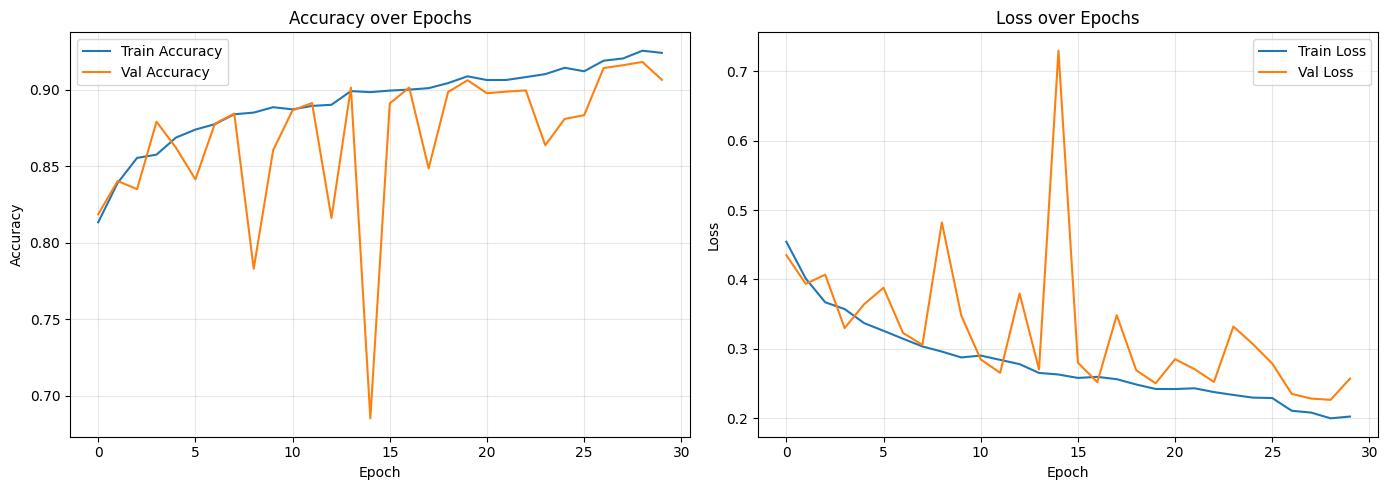

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Evaluate on Test Set

In [20]:
test_steps = math.ceil(test_generator.samples / BATCH_SIZE)
results = model.evaluate(test_generator, steps=test_steps, verbose=1)

for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9121 - auc: 0.9697 - loss: 0.2332 - precision: 0.9266 - recall: 0.8705
loss: 0.2332
compile_metrics: 0.9121


## 13. Detailed Evaluation Metrics

In [21]:
test_generator.reset()
y_pred_probs = model.predict(test_generator, steps=test_steps, verbose=1).ravel()

n_test = test_generator.samples
y_pred_probs = y_pred_probs[:n_test]
y_true = test_generator.classes[:n_test]
y_pred = (y_pred_probs >= 0.5).astype(int)

print("Overall Test Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step
Overall Test Accuracy: 0.9120616365568545

Classification Report:

                precision    recall  f1-score   support

    degradable     0.9017    0.9451    0.9229      2096
non_degradable     0.9266    0.8705    0.8977      1668

      accuracy                         0.9121      3764
     macro avg     0.9141    0.9078    0.9103      3764
  weighted avg     0.9127    0.9121    0.9117      3764



In [22]:
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None)

print(f"{'Class':<16}{'Precision':<12}{'Recall':<12}{'F1-Score':<12}{'Support':<10}")
for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls:<16}{precision[i]:<12.4f}{recall[i]:<12.4f}{f1[i]:<12.4f}{support[i]:<10}")

macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

print(f"\nMacro Avg    -> Precision: {macro_p:.4f}, Recall: {macro_r:.4f}, F1: {macro_f1:.4f}")
print(f"Weighted Avg -> Precision: {weighted_p:.4f}, Recall: {weighted_r:.4f}, F1: {weighted_f1:.4f}")

Class           Precision   Recall      F1-Score    Support   
degradable      0.9017      0.9451      0.9229      2096      
non_degradable  0.9266      0.8705      0.8977      1668      

Macro Avg    -> Precision: 0.9141, Recall: 0.9078, F1: 0.9103
Weighted Avg -> Precision: 0.9127, Recall: 0.9121, F1: 0.9117


### Confusion Matrix

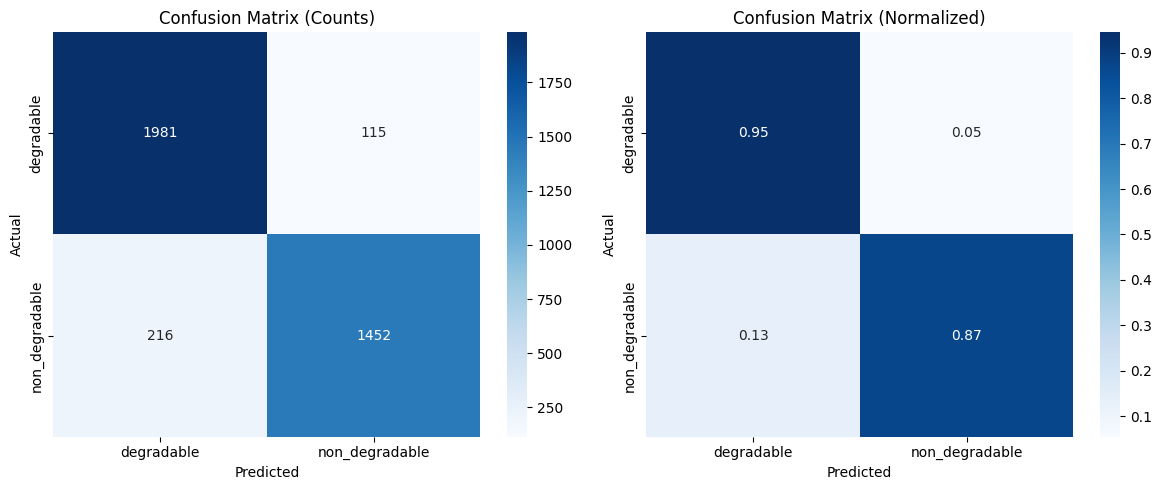

In [23]:
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### ROC Curve (Binary)

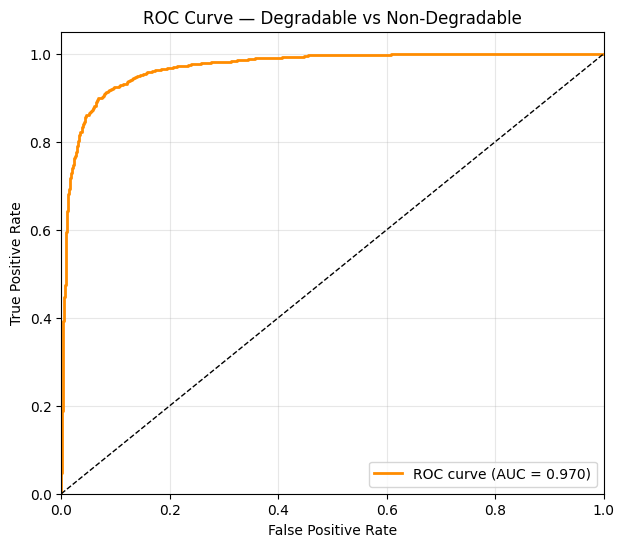

ROC-AUC: 0.9701


In [24]:
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_value:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Degradable vs Non-Degradable')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"ROC-AUC: {roc_auc_score(y_true, y_pred_probs):.4f}")

## 14. Save Final Model

In [25]:
model.save("waste_classifier_binary_native_cnn_scratch.keras")
print("Model saved as waste_classifier_binary_native_cnn_scratch.h5")


Model saved as waste_classifier_binary_native_cnn_scratch.h5


## 15. Inference on a New Image

In [26]:
def classify_image(img_path, model, class_names, img_size=IMG_SIZE, threshold=0.5):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image at {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (img_size, img_size))
    img_normalized = img_resized.astype(np.float32) / 255.0
    img_batch = np.expand_dims(img_normalized, axis=0)

    prob = float(model.predict(img_batch, verbose=0)[0][0])
    predicted_idx = int(prob >= threshold)
    predicted_class = class_names[predicted_idx]
    confidence = prob if predicted_idx == 1 else (1 - prob)

    plt.imshow(img_resized)
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class} ({confidence*100:.2f}% confidence)")
    plt.show()

    print(f"P(non_degradable) = {prob:.4f}  |  P(degradable) = {1 - prob:.4f}")
    return predicted_class, confidence

# Example usage (replace with a real path to test):
# classify_image('path/to/your/test_image.jpg', model, CLASS_NAMES)

## Notes

- **Dataset source**: this notebook downloads a dataset that is *natively* 2-class
  (Organic/Recyclable), rather than remapping TrashNet's 6 classes — see Section 2/3.
- **No pretrained weights** are used anywhere — the CNN trains from random initialization only.
- If you don't want to authenticate with Kaggle, manually download the ZIP from the dataset page
  and place it in a folder named `waste-classification-data` next to this notebook, then run from
  Section 3 onward.
- If training still stops noticeably before 60 epochs, that means `val_loss` genuinely plateaued
  for 20 straight epochs — consider more augmentation or a different model capacity at that point.
- Use `waste_classifier_binary_native.tflite` for edge deployment (Raspberry Pi / Jetson Nano).